# Random Neurons vs Random Forest (Revised)

Implementação revisada com melhorias conceituais e experimentais.

In [53]:
import numpy as np
from sklearn.utils import resample
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
from matplotlib import pyplot as plt

np.random.seed(42)


In [54]:
class PocketPerceptron:
    def __init__(self, max_iter=100):
        self.max_iter = max_iter

    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]
        self.w = np.zeros(X.shape[1])
        best_w = self.w.copy()
        best_error = np.inf

        for _ in range(self.max_iter):
            errors = 0
            for i in range(len(X)):
                if y[i] * np.dot(self.w, X[i]) <= 0:
                    self.w += y[i] * X[i]
                    errors += 1

            if errors < best_error:
                best_error = errors
                best_w = self.w.copy()

        self.w = best_w

    def decision_function(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return np.dot(X, self.w)


In [55]:
class OVRPocket:
    def __init__(self, max_iter=100):
        self.max_iter = max_iter
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            y_bin = np.where(y == c, 1, -1)
            model = PocketPerceptron(self.max_iter)
            model.fit(X, y_bin)
            self.models[c] = model

    def predict(self, X):
        scores = []
        for c in self.classes:
            scores.append(self.models[c].decision_function(X))
        scores = np.array(scores).T
        return self.classes[np.argmax(scores, axis=1)]


In [56]:
class RandomNeurons:
    def __init__(self, L=10, M=100):
        self.L = L
        self.M = M

    def fit(self, X, y):
        self.models = []
        self.features_idx = []
        n_features = X.shape[1]

        for _ in range(self.L):
            X_boot, y_boot = resample(X, y, random_state=42)

            k = np.random.randint(1, n_features + 1)
            idx = np.random.choice(n_features, k, replace=False)

            model = OVRPocket(max_iter=self.M)
            model.fit(X_boot[:, idx], y_boot)

            self.models.append(model)
            self.features_idx.append(idx)

    def predict(self, X):
        preds = []
        for model, idx in zip(self.models, self.features_idx):
            preds.append(model.predict(X[:, idx]))

        preds = np.array(preds).T
        final = [Counter(row).most_common(1)[0][0] for row in preds]
        return np.array(final)


In [57]:
def evaluate(dataset, name):
    X, y = dataset.data, dataset.target

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )


    results = {}
    rf_results = {}

    print(f"\nDataset: {name}")

    for L in [5, 10, 20]:
        results[L] = {}

        for M in [50, 100, 200]:
            rn = RandomNeurons(L=L, M=M)
            rn.fit(X_train, y_train)
            pred = rn.predict(X_test)
            acc = accuracy_score(y_test, pred)

            results[L][M] = acc
            print(f"Random Neurons (L={L}, M={M}) -> {acc:.4f}")

        rf = RandomForestClassifier(
            n_estimators=L,
            max_depth=None,
            min_samples_split=2,
            random_state=42
        )
        rf.fit(X_train, y_train)
        pred_rf = rf.predict(X_test)
        acc_rf = accuracy_score(y_test, pred_rf)

        rf_results[L] = acc_rf
        print(f"Random Forest (L={L}) -> {acc_rf:.4f}")

    return results, rf_results

In [58]:
iris_data, iris_rf = evaluate(load_iris(), "Iris")
wine_data, wine_rf = evaluate(load_wine(), "Wine")


Dataset: Iris
Random Neurons (L=5, M=50) -> 0.8222
Random Neurons (L=5, M=100) -> 0.9111
Random Neurons (L=5, M=200) -> 0.7778
Random Forest (L=5) -> 1.0000
Random Neurons (L=10, M=50) -> 0.8667
Random Neurons (L=10, M=100) -> 0.8889
Random Neurons (L=10, M=200) -> 0.7556
Random Forest (L=10) -> 1.0000
Random Neurons (L=20, M=50) -> 0.8889
Random Neurons (L=20, M=100) -> 0.8444
Random Neurons (L=20, M=200) -> 0.7556
Random Forest (L=20) -> 1.0000

Dataset: Wine
Random Neurons (L=5, M=50) -> 0.9444
Random Neurons (L=5, M=100) -> 1.0000
Random Neurons (L=5, M=200) -> 0.9630
Random Forest (L=5) -> 0.9259
Random Neurons (L=10, M=50) -> 0.9630
Random Neurons (L=10, M=100) -> 1.0000
Random Neurons (L=10, M=200) -> 0.9815
Random Forest (L=10) -> 0.9259
Random Neurons (L=20, M=50) -> 1.0000
Random Neurons (L=20, M=100) -> 1.0000
Random Neurons (L=20, M=200) -> 1.0000
Random Forest (L=20) -> 0.9630


In [59]:
def plot_dataset(data, rf_data, title, save_path=None):
    plt.figure()

    colors = {
        5: 'C0',
        10: 'C1',
        20: 'C2'
    }

    for L, values in data.items():
        M_vals = sorted(values.keys())
        acc_vals = [values[m] for m in M_vals]
        plt.plot(
            M_vals,
            acc_vals,
            marker='o',
            linestyle='-',
            color=colors[L],
            label=f'Random Neurons (L={L})',
        )

    for L, acc in rf_data.items():
        plt.axhline(
            y=acc,
            linestyle='--',
            color=colors[L],
            label=f'Random Forest (L={L})',
        )

    plt.title(title)
    plt.xlabel('M (iterações do Perceptron)')
    plt.ylabel('Acurácia')
    plt.ylim(0.6, 1.05)  # 🔥 melhora comparabilidade
    plt.grid()

    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    plt.show()

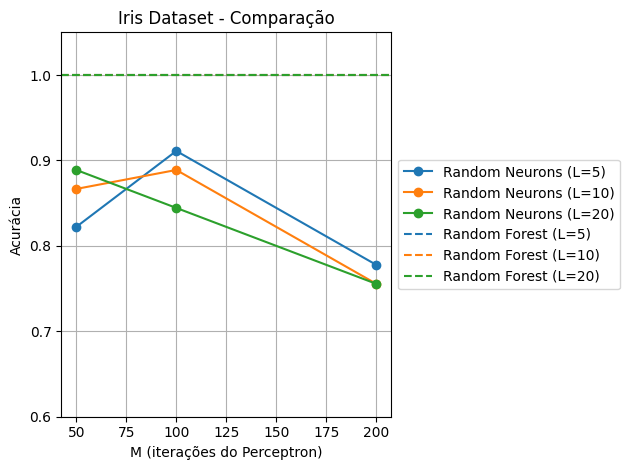

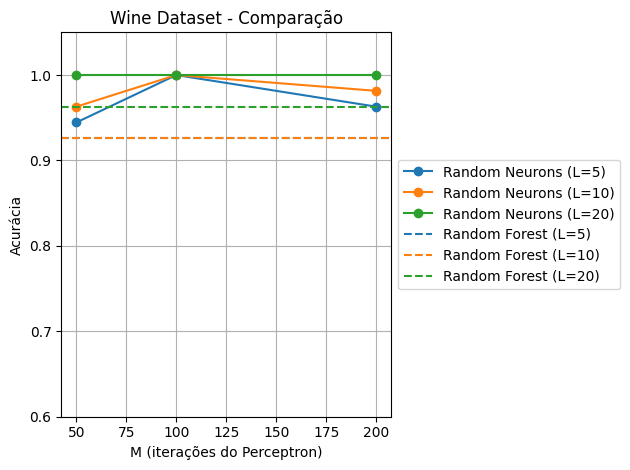

In [60]:
plot_dataset(iris_data, iris_rf, 'Iris Dataset - Comparação', save_path='images/iris.png')
plot_dataset(wine_data, wine_rf, 'Wine Dataset - Comparação', save_path='images/wine.png')

In [61]:
def to_percent_table(data_dict, rf_dict):
    lines = []
    for L in [5, 10, 20]:
        row = [L] + [100*data_dict[L][M] for M in [50, 100, 200]] + [100*rf_dict[L]]
        lines.append(row)
    return lines

def pretty_print(name, data_dict, rf_dict):
    print(f"\n{name}")
    print("L\tM=50\tM=100\tM=200\tRF")
    for L, m50, m100, m200, rf in to_percent_table(data_dict, rf_dict):
        print(f"{L}\t{m50:.2f}\t{m100:.2f}\t{m200:.2f}\t{rf:.2f}")

pretty_print("Iris", iris_data, iris_rf)
pretty_print("Wine", wine_data, wine_rf)


Iris
L	M=50	M=100	M=200	RF
5	82.22	91.11	77.78	100.00
10	86.67	88.89	75.56	100.00
20	88.89	84.44	75.56	100.00

Wine
L	M=50	M=100	M=200	RF
5	94.44	100.00	96.30	92.59
10	96.30	100.00	98.15	92.59
20	100.00	100.00	100.00	96.30
